<a href="https://colab.research.google.com/github/YuriiKlim/Amazinum_Camp/blob/Homeworks/Lesson8_HW_decision_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home Task
## Brest cancer dataset

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%matplotlib notebook

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X, y, labels, features = cancer.data, cancer.target, cancer.target_names, cancer.feature_names
print ('labels:',labels)
print ('features:', features)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

labels: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [5]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 9.2 MB/s eta 0:00:00


In [19]:
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

def tune_hyperparameters(X_train, X_test, y_train, y_test, algorithm, n_trials):
    """
    A function for optimizing hyperparameters with Optuna for a given algorithm.

    Params:
        X_train, X_test, y_train, y_test - training and test data.
        algorithm - name of the algorithm (one of them: "DT" - DecisionTree, "RF" - RandomForest,
                                          "GBDT" - Gradient Boosting Decision Trees, "XGB" - XGBoost).
        n_trials - the number of optimization iterations.

    Return:
        Dictionary with optimal hyperparameters.
    """

    def objective(trial):
        if algorithm == "DT":
            max_depth = trial.suggest_int("max_depth", 1, 64)
            min_samples_split = trial.suggest_int("min_samples_split", 2, 50)
            min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 50)
            model = DecisionTreeClassifier(max_depth=max_depth,
                                           min_samples_split=min_samples_split,
                                           min_samples_leaf=min_samples_leaf,
                                           random_state=42)

        elif algorithm == "RF":
            n_estimators = trial.suggest_int("n_estimators", 50, 300)
            max_depth = trial.suggest_int("max_depth", 1, 64)
            min_samples_split = trial.suggest_int("min_samples_split", 2, 50)
            min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 50)
            model = RandomForestClassifier(n_estimators=n_estimators,
                                           max_depth=max_depth,
                                           min_samples_split=min_samples_split,
                                           min_samples_leaf=min_samples_leaf,
                                           random_state=42)

        elif algorithm == "GBDT":
            n_estimators = trial.suggest_int("n_estimators", 50, 300)
            learning_rate = trial.suggest_float("learning_rate", 0.001, 0.3)
            max_depth = trial.suggest_int("max_depth", 1, 50)
            subsample = trial.suggest_float("subsample", 0.5, 1.0)
            model = GradientBoostingClassifier(n_estimators=n_estimators,
                                               learning_rate=learning_rate,
                                               max_depth=max_depth,
                                               subsample=subsample,
                                               random_state=42)

        elif algorithm == "XGB":
            n_estimators = trial.suggest_int("n_estimators", 50, 300)
            learning_rate = trial.suggest_float("learning_rate", 0.001, 0.3)
            max_depth = trial.suggest_int("max_depth", 1, 50)
            subsample = trial.suggest_float("subsample", 0.5, 1.0)
            colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
            model = XGBClassifier(n_estimators=n_estimators,
                                  learning_rate=learning_rate,
                                  max_depth=max_depth,
                                  subsample=subsample,
                                  colsample_bytree=colsample_bytree,
                                  eval_metric='logloss',
                                  random_state=42)
        else:
            raise ValueError(f"Unsupported algorithm: {algorithm}")

        # Model training
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = accuracy_score(y_test, y_pred)

        # Since Optuna minimizes the objective function, we return (1 - accuracy)
        return 1 - score

    # Creating and optimizing research
    study = optuna.create_study()
    study.optimize(objective, n_trials=n_trials)

    return study.best_params

# DecisionTree

In [7]:
best_params = tune_hyperparameters(X_train, X_test, y_train, y_test, "DT", 500)

best_params

{'max_depth': 21, 'min_samples_split': 38, 'min_samples_leaf': 13}

In [10]:
from sklearn import tree
import graphviz

# YOUR_CODE.  create the classifier and train it
# START_CODE
clf = DecisionTreeClassifier(**best_params, random_state=42)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
graph_viz = tree.export_graphviz(clf, out_file=None,feature_names=features, class_names=labels, filled = True)
graph = graphviz.Source(graph_viz)
graph.view(cleanup =True) # cleanup (bool) – Delete the source file after rendering.

train accuracy= 93.662%
test accuracy= 93.706%


'Source.gv.pdf'

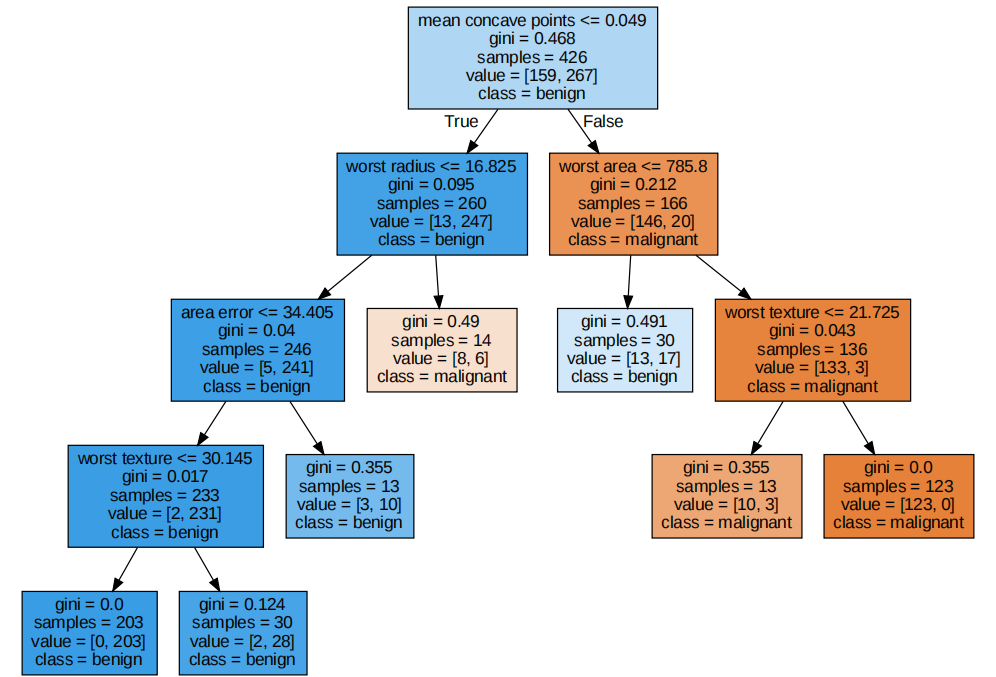

# RandomForest

In [11]:
best_params = tune_hyperparameters(X_train, X_test, y_train, y_test, "RF", 500)

best_params

{'n_estimators': 115,
 'max_depth': 54,
 'min_samples_split': 30,
 'min_samples_leaf': 43}

In [13]:
# YOUR_CODE.  create the classifier and train it
# START_CODE
clf = RandomForestClassifier(**best_params, random_state=42)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 94.836%
test accuracy= 97.203%


# Gradient Boosting Decision Trees (GBDT)

In [14]:
best_params = tune_hyperparameters(X_train, X_test, y_train, y_test, "GBDT", 500)

best_params

{'n_estimators': 73,
 'learning_rate': 0.2239847399886005,
 'max_depth': 6,
 'subsample': 0.8662274583656273}

In [15]:
# YOUR_CODE.  create the classifier and train it
# START_CODE
clf = GradientBoostingClassifier(**best_params, random_state=42)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 99.301%


# XGBoost

In [20]:
best_params = tune_hyperparameters(X_train, X_test, y_train, y_test, "XGB", 500)

best_params

{'n_estimators': 237,
 'learning_rate': 0.17185597325111382,
 'max_depth': 35,
 'subsample': 0.5670821307764492,
 'colsample_bytree': 0.6132410260234102}

In [22]:
# YOUR_CODE.  create the classifier and train it
# START_CODE
clf = XGBClassifier(**best_params, eval_metric='logloss', random_state=42)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 100.000%
